In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import sklearn
import os
import seaborn as sns

- How many Movies vs TV Shows are there, and how has the ratio changed per year?
- In which years did Netflix add the most content?
- Which countries produce the most content?
- What are the top genres, for movies and for TV shows separately?
- What is the typical movie length, and how many seasons do most shows have?
- Which age ratings (TV-MA, TV-14, etc.) dominate?
- How much time passes between release year and the date Netflix added a title?
- Which directors and actors appear most?

In [37]:
data_dir = '/kaggle/input/'
for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file))

file_path = '/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv'
df = pd.read_csv(file_path)
df.head()

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [38]:
df.shape

(8807, 12)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [40]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Clean the data

In [41]:
df = df.drop_duplicates()

# A few rows have the duration typed into the "rating" column - fix them
mask = df["rating"].astype(str).str.contains("min")
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = "Unknown"

# Fill missing text values
for col in ["director", "cast", "country", "rating"]:
    df[col] = df[col].fillna("Unknown")

# Dates
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

# Duration as a number (minutes for movies, seasons for TV shows)
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)

df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
duration_num     0
dtype: int64

/tmp/ipykernel_58/2671555843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ratings.index, y=top_10_ratings.values, palette='viridis')


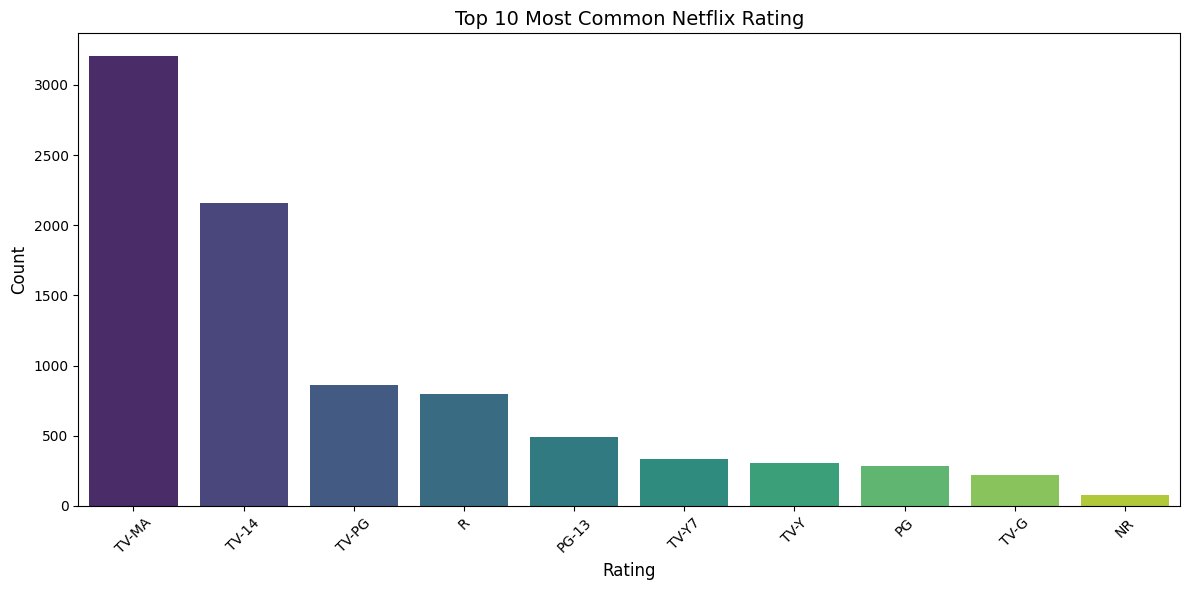

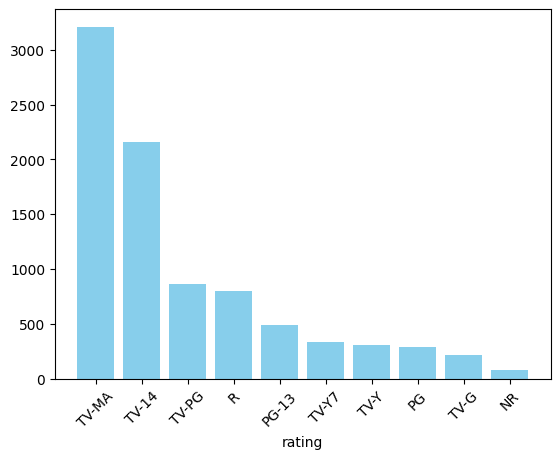

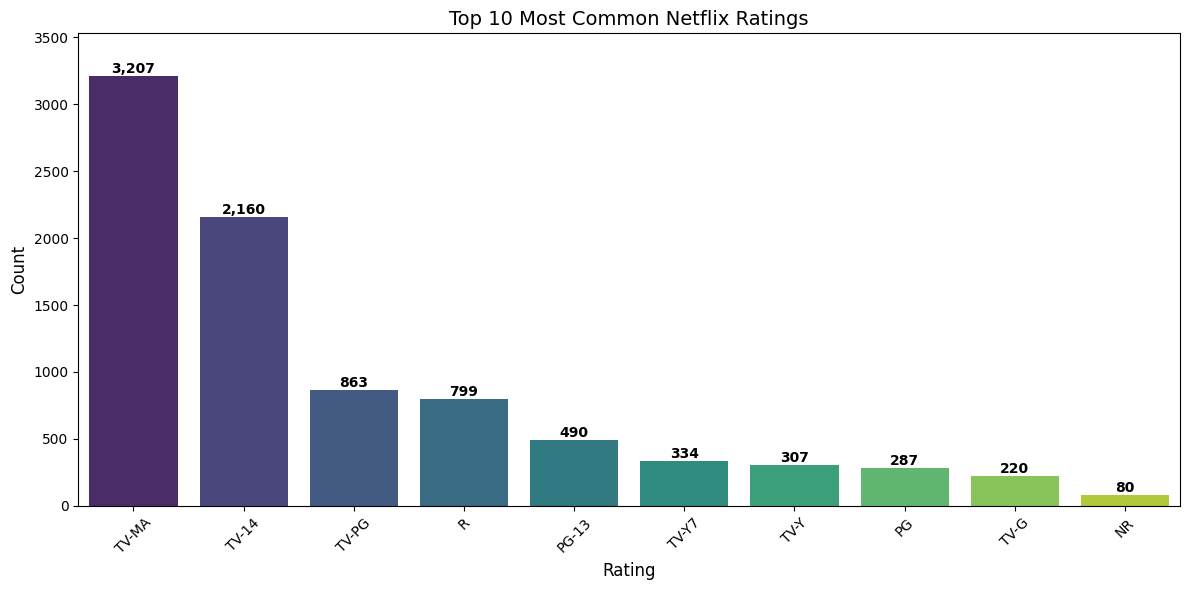

In [42]:
top_10_ratings = df['rating'].value_counts().head(10)
#1
# # chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_ratings.index, y=top_10_ratings.values, palette='viridis')

plt.title('Top 10 Most Common Netflix Rating', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2
sns.barplot(
     x=top_10_ratings.index,
     y=top_10_ratings.values,
     hue=top_10_ratings.index,  # assign x to hue
     palette='viridis',
     legend=False               # hide legend since it's redundant
 )

# 3
plt.bar(top_10_ratings.index, top_10_ratings.values, color='skyblue')
plt.xticks(rotation=45)

# 4
# Create the chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_10_ratings.index,
    y=top_10_ratings.values,
    hue=top_10_ratings.index,
    palette='viridis',
    legend=False
)

# Add exact number labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}',           # format with commas (e.g., 1,234)
        (p.get_x() + p.get_width() / 2., height),
        ha='center',                  # horizontal alignment
        va='bottom',                  # vertical alignment
        fontsize=10,
        fontweight='bold'
    )

# Add a little headroom so labels aren't cut off
ax.set_ylim(0, max(top_10_ratings.values) * 1.1)

plt.title('Top 10 Most Common Netflix Ratings', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There is big number of director pull and heighest one director in multuple movie is 

# How many Movies vs TV Shows, and how has the ratio changed per year? 

<Axes: xlabel='count', ylabel='type'>

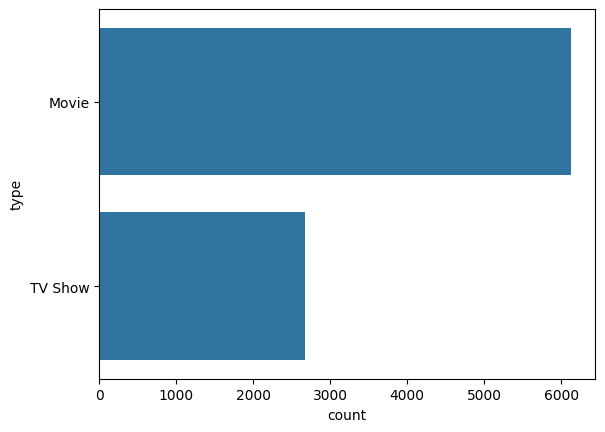

In [43]:
sns.countplot(df['type']) 

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: count, dtype: float64


/tmp/ipykernel_58/2784945437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="type", palette="Set2")


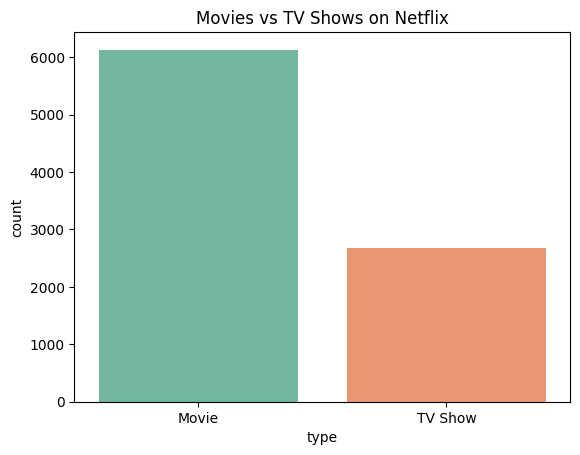

In [44]:
counts = df["type"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(1))

sns.countplot(data=df, x="type", palette="Set2")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

type        Movie  TV Show  movie_share_%
year_added                               
2008.0          1        1           50.0
2009.0          2        0          100.0
2010.0          1        0          100.0
2011.0         13        0          100.0
2012.0          3        0          100.0
2013.0          6        5           54.5
2014.0         19        5           79.2
2015.0         56       26           68.3
2016.0        253      176           59.0
2017.0        839      349           70.6
2018.0       1237      412           75.0
2019.0       1424      592           70.6
2020.0       1284      595           68.3
2021.0        993      505           66.3


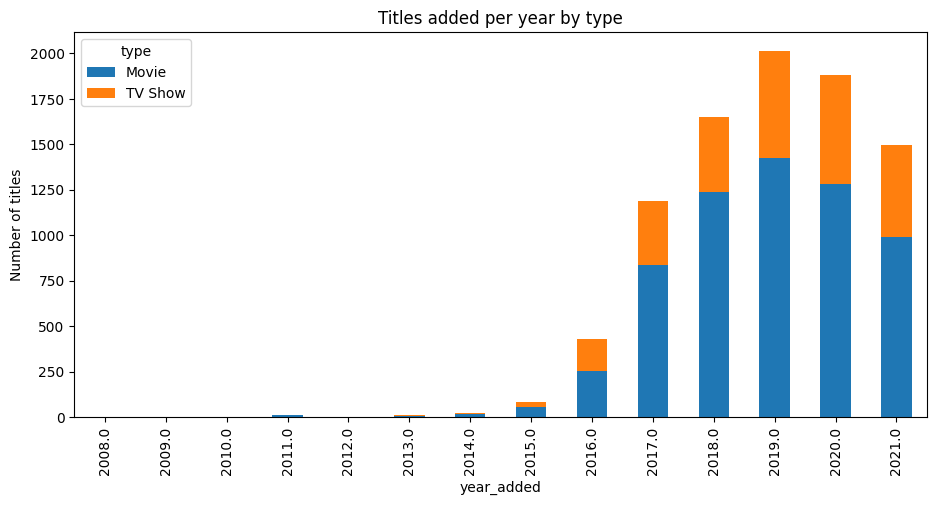

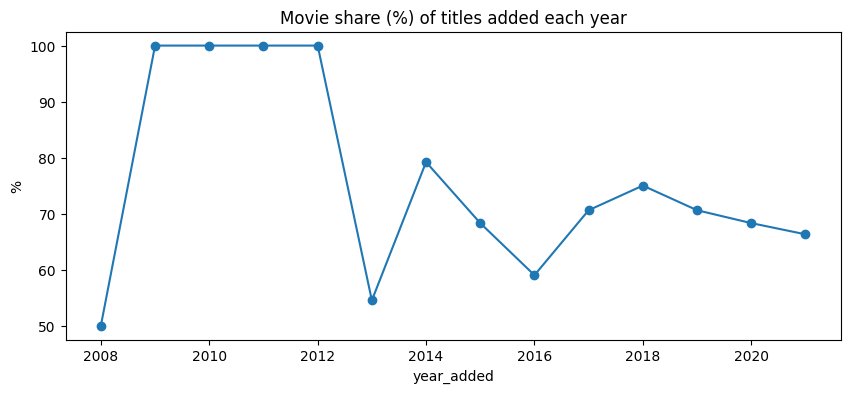

In [45]:
type_year = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
type_year["movie_share_%"] = (type_year["Movie"] / (type_year["Movie"] + type_year["TV Show"]) * 100).round(1)
print(type_year)

type_year[["Movie", "TV Show"]].plot(kind="bar", stacked=True, figsize=(11, 5))
plt.title("Titles added per year by type")
plt.ylabel("Number of titles")
plt.show()

type_year["movie_share_%"].plot(marker="o", figsize=(10, 4))
plt.title("Movie share (%) of titles added each year")
plt.ylabel("%")
plt.show()

# In which years did Netflix add the most content?

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

Peak year: 2019.0 with 2016 titles


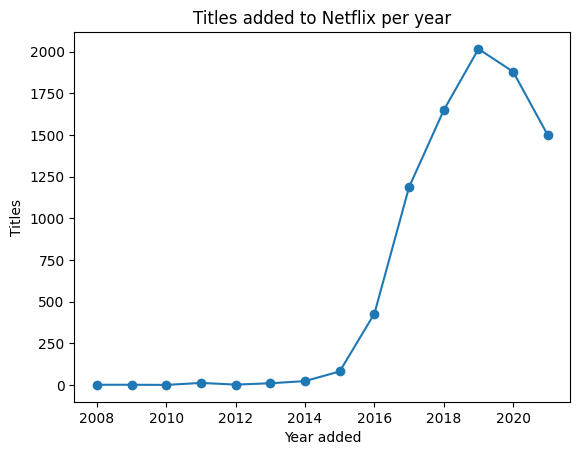

In [46]:
added_per_year = df["year_added"].value_counts().sort_index()
print(added_per_year)
print("\nPeak year:", added_per_year.idxmax(), "with", added_per_year.max(), "titles")

added_per_year.plot(kind="line", marker="o")
plt.title("Titles added to Netflix per year")
plt.xlabel("Year added")
plt.ylabel("Titles")
plt.show()

# Which countries produce the most content?

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


/tmp/ipykernel_58/2086487754.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


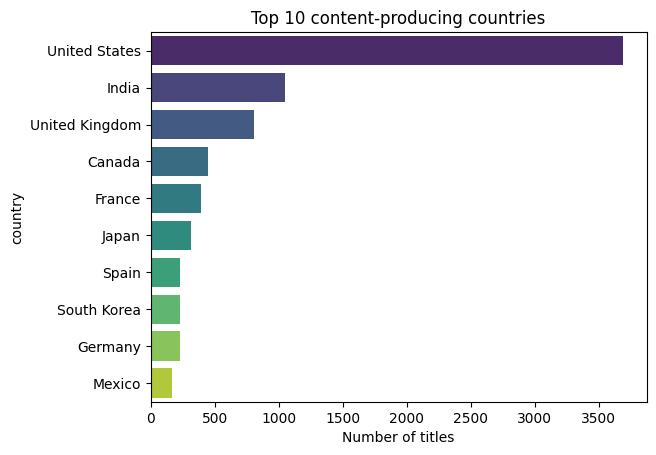

In [47]:
countries = df.assign(country=df["country"].str.split(",")).explode("country")
countries["country"] = countries["country"].str.strip()
countries = countries[~countries["country"].isin(["", "Unknown"])]

top_countries = countries["country"].value_counts().head(10)
print(top_countries)

sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 content-producing countries")
plt.xlabel("Number of titles")
plt.show()

# Top genres for movies and TV shows separately


Top genres - Movie
 genre
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

Top genres - TV Show
 genre
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: count, dtype: int64


/tmp/ipykernel_58/1183200313.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=ax, palette="mako")
/tmp/ipykernel_58/1183200313.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=ax, palette="mako")


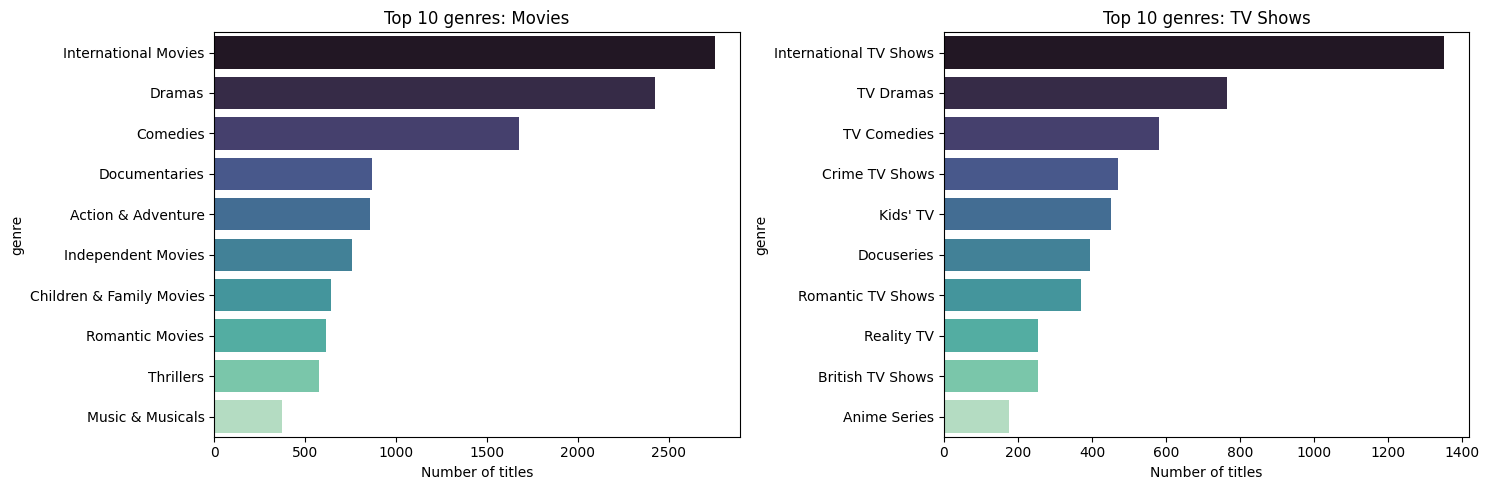

In [48]:
genres = df.assign(genre=df["listed_in"].str.split(",")).explode("genre")
genres["genre"] = genres["genre"].str.strip()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, t in zip(axes, ["Movie", "TV Show"]):
    top = genres[genres["type"] == t]["genre"].value_counts().head(10)
    print(f"\nTop genres - {t}\n", top)
    sns.barplot(x=top.values, y=top.index, ax=ax, palette="mako")
    ax.set_title(f"Top 10 genres: {t}s")
    ax.set_xlabel("Number of titles")
plt.tight_layout()
plt.show()

# Typical movie length and number of seasons

Movie duration (minutes):
count    6131.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: duration_num, dtype: float64

Seasons per TV show:
duration_num
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64


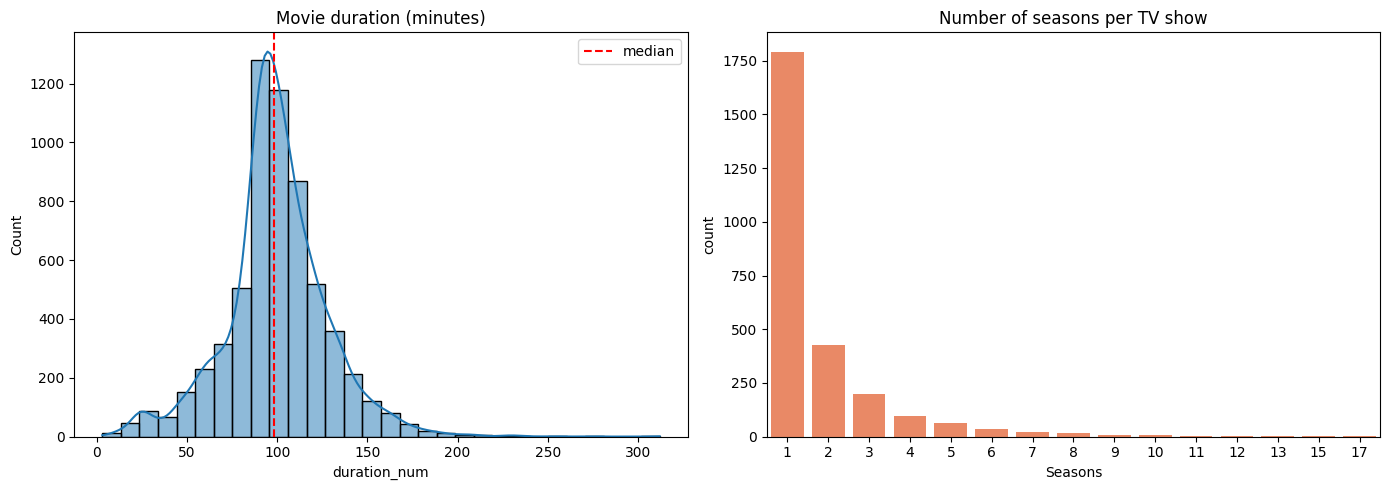

In [49]:
movies = df[df["type"] == "Movie"]
shows = df[df["type"] == "TV Show"]

print("Movie duration (minutes):")
print(movies["duration_num"].describe().round(1))
print("\nSeasons per TV show:")
print(shows["duration_num"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(movies["duration_num"].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title("Movie duration (minutes)")
axes[0].axvline(movies["duration_num"].median(), color="red", linestyle="--", label="median")
axes[0].legend()

sns.countplot(x=shows["duration_num"].dropna().astype(int), ax=axes[1], color="coral")
axes[1].set_title("Number of seasons per TV show")
axes[1].set_xlabel("Seasons")

plt.tight_layout()
plt.show()

# Which age ratings dominate?

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


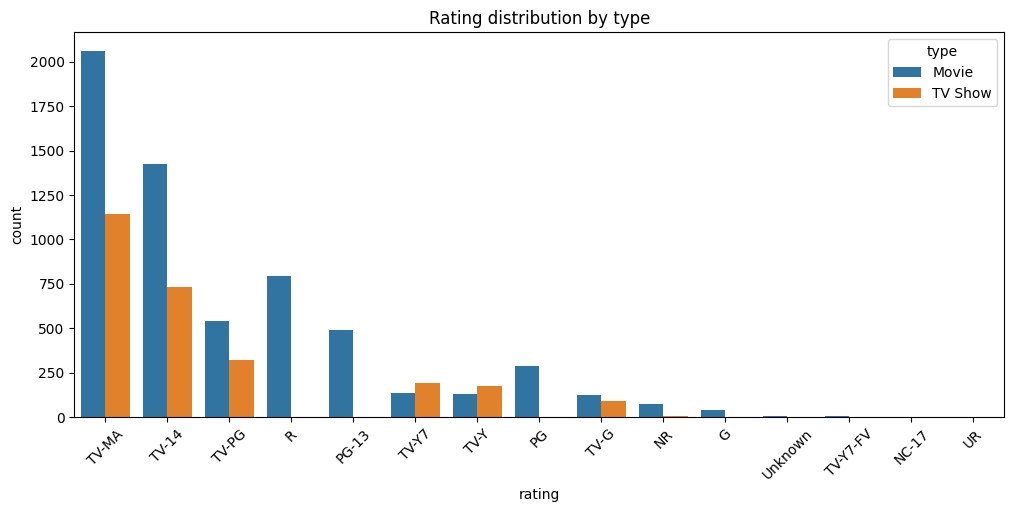

In [50]:
rating_order = df["rating"].value_counts().index
print(df["rating"].value_counts())

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="rating", hue="type", order=rating_order)
plt.title("Rating distribution by type")
plt.xticks(rotation=45)
plt.show()

# Time between release year and date added

count    8783.0
mean        4.7
std         8.8
min         0.0
25%         0.0
50%         1.0
75%         5.0
max        93.0
Name: gap_years, dtype: float64

Share added within 1 year of release: 54.9 %


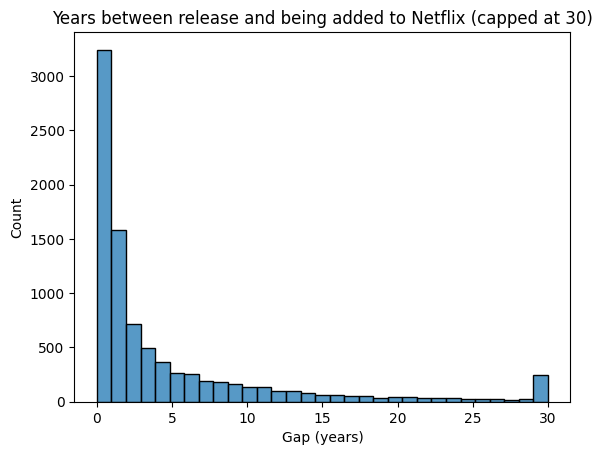


Longest gaps:


,title,type,release_year,year_added,gap_years
4250,Pioneers: First Women Filmmakers*,TV Show,1925,2018.0,93.0
1331,Five Came Back: The Reference Films,TV Show,1945,2021.0,76.0
7790,Prelude to War,Movie,1942,2017.0,75.0
8205,The Battle of Midway,Movie,1942,2017.0,75.0
8763,WWII: Report from the Aleutians,Movie,1943,2017.0,74.0
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943,2017.0,74.0
8739,Why We Fight: The Battle of Russia,Movie,1943,2017.0,74.0
8436,The Negro Soldier,Movie,1944,2017.0,73.0
8419,The Memphis Belle: A Story of a\nFlying Fortress,Movie,1944,2017.0,73.0
8640,Tunisian Victory,Movie,1944,2017.0,73.0


In [51]:
df["gap_years"] = df["year_added"] - df["release_year"]
valid = df[df["gap_years"] >= 0]  # ignore rare bad rows with negative gaps

print(valid["gap_years"].describe().round(1))
print("\nShare added within 1 year of release:",
      round((valid["gap_years"] <= 1).mean() * 100, 1), "%")

sns.histplot(valid["gap_years"].clip(upper=30), bins=31)
plt.title("Years between release and being added to Netflix (capped at 30)")
plt.xlabel("Gap (years)")
plt.show()

print("\nLongest gaps:")
valid.sort_values("gap_years", ascending=False)[["title", "type", "release_year", "year_added", "gap_years"]].head(10)

# Auto-generate your insights (starter)

/tmp/ipykernel_58/3401636167.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[0], palette="rocket")
/tmp/ipykernel_58/3401636167.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, ax=axes[1], palette="crest")


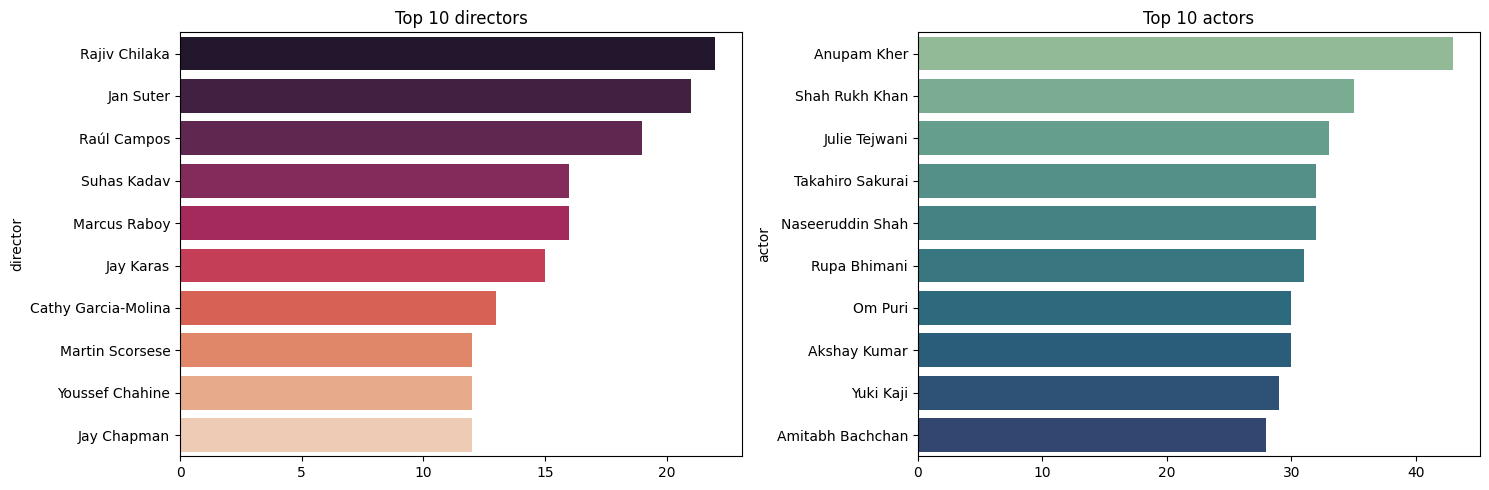

In [52]:
# Directors
directors = df.assign(director=df["director"].str.split(",")).explode("director")
directors["director"] = directors["director"].str.strip()
directors = directors[directors["director"] != "Unknown"]
top_directors = directors["director"].value_counts().head(10)

# Actors
actors = df.assign(actor=df["cast"].str.split(",")).explode("actor")
actors["actor"] = actors["actor"].str.strip()
actors = actors[actors["actor"] != "Unknown"]
top_actors = actors["actor"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[0], palette="rocket")
axes[0].set_title("Top 10 directors")
sns.barplot(x=top_actors.values, y=top_actors.index, ax=axes[1], palette="crest")
axes[1].set_title("Top 10 actors")
plt.tight_layout()
plt.show()

# Auto-generate your insights (starter)

In [53]:
print("INSIGHTS")
print("-" * 40)
print(f"1. Movies are {counts['Movie'] / counts.sum() * 100:.0f}% of the catalog; TV shows are {counts['TV Show'] / counts.sum() * 100:.0f}%.")
print(f"2. Peak year for additions: {added_per_year.idxmax()} ({added_per_year.max()} titles).")
print(f"3. Top producing country: {top_countries.index[0]} ({top_countries.iloc[0]} titles).")
print(f"4. Top movie genre: {genres[genres['type']=='Movie']['genre'].value_counts().index[0]}.")
print(f"5. Median movie length: {movies['duration_num'].median():.0f} min; most common season count: {int(shows['duration_num'].mode()[0])}.")
print(f"6. Most common rating: {df['rating'].value_counts().index[0]}.")
print(f"7. Median gap between release and add: {valid['gap_years'].median():.0f} years.")
print(f"8. Most frequent director: {top_directors.index[0]}; most frequent actor: {top_actors.index[0]}.")

INSIGHTS
----------------------------------------
1. Movies are 70% of the catalog; TV shows are 30%.
2. Peak year for additions: 2019.0 (2016 titles).
3. Top producing country: United States (3690 titles).
4. Top movie genre: International Movies.
5. Median movie length: 98 min; most common season count: 1.
6. Most common rating: TV-MA.
7. Median gap between release and add: 1 years.
8. Most frequent director: Rajiv Chilaka; most frequent actor: Anupam Kher.
